# Colten Wasden
cleanup of the inflation dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## First thing
We are going to load in our inflation dataset and labels
With them both loaded we will then have to map the labels onto the inflation DF

In [2]:
inflation_labels = {}
# reading txt doc and creating a dict to map onto dataset
with open('inflation_ids.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        label, code = line.rsplit(' - ', 1)
        inflation_labels[code.strip()] = label.strip()

print(inflation_labels)

{'APU0000704111': 'Bacon, sliced, per lb.', 'APU0000711211': 'Bananas, per lb.', 'APU0000702111': 'Bread, white, pan, per lb.', 'APU0000706111': 'Chicken, fresh, whole, per lb.', 'APU0000717311': 'Coffee, 100%, ground roast, all sizes, per lb.', 'APU0000708111': 'Eggs, grade A, large, per doz.', 'APU0000701111': 'Flour, white, all purpose, per lb.', 'APU0000709112': 'Milk, fresh, whole, fortified, per gal.', 'APU0000711311': 'Oranges, navel, per lb.', 'APU0000701312': 'Rice, white, long grain, uncooked, per lb.', 'APU0000712311': 'Tomatoes, field grown, per lb.', 'APU000072610': 'Electricity per KWH', 'APU000072511': 'Fuel oil #2 per gallon', 'APU00007471A': 'Gasoline, all types, per gallon', 'APU000074714': 'Gasoline, unleaded regular, per gallon'}


In [3]:
inflation_df = pd.read_csv('Dataset #2 - inflation.txt')
inflation_df = inflation_df.rename(columns={'Series ID': 'series_id'})

#mapping labels onto correlating rows in dataset

inflation_df.insert(1, 'label', inflation_df['series_id'].map(inflation_labels))
inflation_df.head()

,series_id,label,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,Jul 2016,Aug 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
0,APU0000704111,"Bacon, sliced, per lb.",5.656,5.394,5.494,5.613,5.552,5.374,5.454,5.448,...,6.801,6.826,,,,,,,,
1,APU0000711211,"Bananas, per lb.",0.581,0.573,0.586,0.574,0.570,0.569,0.567,0.562,...,0.657,0.654,,,,,,,,
2,APU0000702111,"Bread, white, pan, per lb.",1.425,1.407,1.416,1.406,1.382,1.333,1.349,1.341,...,1.808,1.869,,,,,,,,
3,APU0000706111,"Chicken, fresh, whole, per lb.",1.429,1.478,1.463,1.496,1.489,1.408,1.445,1.426,...,2.033,2.026,,,,,,,,
4,APU0000717311,"Coffee, 100%, ground roast, all sizes, per lb.",4.498,4.447,4.405,4.428,4.443,4.481,4.428,4.316,...,9.608,9.723,,,,,,,,


## Headcount
The headcount dataset is a tracker of how many people are working in each sector throughout the US. The monthly amount is how many there are total each month.    
We need to read this one and the labels in just like the one above

In [4]:
headcount = pd.read_csv('Dataset #1 - earnings.txt')
headcount_labels = pd.read_csv('earnings_ids.txt', sep='\t')
print(headcount.head())
print(headcount_labels.head())

       Series ID  Jan 2016  Feb 2016  Mar 2016  Apr 2016  May 2016  Jun 2016  \
0  CEU0000000001  141073.0  141900.0  142797.0  143892.0  144541.0  145205.0   
1  CES0000000001  143210.0  143406.0  143662.0  143854.0  143900.0  144147.0   
2  CEU0500000001  119093.0  119487.0  120245.0  121313.0  122001.0  123099.0   
3  CES0500000001  121096.0  121268.0  121484.0  121670.0  121701.0  121967.0   
4  CEU0600000001   19238.0   19214.0   19341.0   19551.0   19707.0   19985.0   

   Jul 2016  Aug 2016  Sep 2016  ...   Mar 2026   Apr 2026  May 2026  \
0  144232.0  144484.0  145149.0  ...  157769(P)  158695(P)             
1  144520.0  144661.0  144967.0  ...  158621(P)  158736(P)             
2  123232.0  123281.0  122910.0  ...  134125(P)  135049(P)             
3  122231.0  122377.0  122644.0  ...  135305(P)  135428(P)             
4   20065.0   20062.0   19976.0  ...   21239(P)   21401(P)             

   Jun 2026  Jul 2026  Aug 2026  Sep 2026  Oct 2026  Nov 2026  Dec 2026  
0           

In [5]:
##Cleaning up the earnings df before merging

date_cols = headcount.columns[1:]                      
# everything except Series ID

headcount[date_cols] = (
    headcount[date_cols]
    .replace(r"\(P\)", "", regex=True)          # drop (P) in headcounts noted as preliminary
    .replace(r"^\s*$", pd.NA, regex=True)       # blank trailing months -> NA
    .apply(pd.to_numeric, errors="coerce")
)
headcount.head()

,Series ID,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,Jul 2016,Aug 2016,Sep 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
0,CEU0000000001,141073.0,141900.0,142797.0,143892.0,144541.0,145205.0,144232.0,144484.0,145149.0,...,157769.0,158695.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CES0000000001,143210.0,143406.0,143662.0,143854.0,143900.0,144147.0,144520.0,144661.0,144967.0,...,158621.0,158736.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CEU0500000001,119093.0,119487.0,120245.0,121313.0,122001.0,123099.0,123232.0,123281.0,122910.0,...,134125.0,135049.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CES0500000001,121096.0,121268.0,121484.0,121670.0,121701.0,121967.0,122231.0,122377.0,122644.0,...,135305.0,135428.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CEU0600000001,19238.0,19214.0,19341.0,19551.0,19707.0,19985.0,20065.0,20062.0,19976.0,...,21239.0,21401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Here we have to clean up the Series IDs because they have encoded the industry code and seasonality in them.

In [6]:
# Merging earnings df and label df.
headcount["industry_code"] = headcount["Series ID"].str[3:11]     #industry code is embedded in the SeriesID
headcount["seasonal"]      = headcount["Series ID"].str[2]   # U = NSA, S = SA -- encoded in series id to inform if seasonal or not
headcount.insert(0, "industry_code", headcount.pop("industry_code"))
headcount.insert(1, "seasonal", headcount.pop("seasonal"))

headcount.head()

/var/folders/7j/6mqynt1d3rn3g84946r88qxr0000gn/T/ipykernel_6443/3781997835.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  headcount["industry_code"] = headcount["Series ID"].str[3:11]     #industry code is embedded in the SeriesID
/var/folders/7j/6mqynt1d3rn3g84946r88qxr0000gn/T/ipykernel_6443/3781997835.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  headcount["seasonal"]      = headcount["Series ID"].str[2]   # U = NSA, S = SA -- encoded in series id to inform if seasonal or not
/var/folders/7j/6mqynt1d3rn3g84946r88qx

,industry_code,seasonal,Series ID,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,Jul 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
0,00000000,U,CEU0000000001,141073.0,141900.0,142797.0,143892.0,144541.0,145205.0,144232.0,...,157769.0,158695.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00000000,S,CES0000000001,143210.0,143406.0,143662.0,143854.0,143900.0,144147.0,144520.0,...,158621.0,158736.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,05000000,U,CEU0500000001,119093.0,119487.0,120245.0,121313.0,122001.0,123099.0,123232.0,...,134125.0,135049.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,05000000,S,CES0500000001,121096.0,121268.0,121484.0,121670.0,121701.0,121967.0,122231.0,...,135305.0,135428.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,06000000,U,CEU0600000001,19238.0,19214.0,19341.0,19551.0,19707.0,19985.0,20065.0,...,21239.0,21401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# normalize lookup key and merge
headcount_labels["industry_code"] = headcount_labels["CES Industry Code"].str.strip().str.replace("-", "", regex=False)
earnings_clean = headcount.merge(
    headcount_labels[["industry_code", "CES Industry Title"]].drop_duplicates("industry_code"),
    on="industry_code", how="left",
)
earnings_clean.insert(0, "CES Industry Title", earnings_clean.pop("CES Industry Title"))

earnings_clean.head()

,CES Industry Title,industry_code,seasonal,Series ID,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
0,Total nonfarm,00000000,U,CEU0000000001,141073.0,141900.0,142797.0,143892.0,144541.0,145205.0,...,157769.0,158695.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total nonfarm,00000000,S,CES0000000001,143210.0,143406.0,143662.0,143854.0,143900.0,144147.0,...,158621.0,158736.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Total private,05000000,U,CEU0500000001,119093.0,119487.0,120245.0,121313.0,122001.0,123099.0,...,134125.0,135049.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Total private,05000000,S,CES0500000001,121096.0,121268.0,121484.0,121670.0,121701.0,121967.0,...,135305.0,135428.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Goods-producing,06000000,U,CEU0600000001,19238.0,19214.0,19341.0,19551.0,19707.0,19985.0,...,21239.0,21401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## The Industry title has been merged onto the df. lets verify they all got mapped correctly.

In [8]:
# verifying no NA in industry title
earnings_clean["CES Industry Title"].isna().sum()

np.int64(0)

# Top Level
Here is the top level, which is the total sum of all of the jobs in a particular sector.   
This will give us a more broad understanding of the sectors and the trends they have.
   
top_level_s = Seasonally adjusted   
top_level_u = not seasonally adjusted

In [9]:
top_level_s = earnings_clean[
    earnings_clean['industry_code'].str.endswith('000000')
    & (earnings_clean['seasonal'] == 'S')
]
top_level_s

,CES Industry Title,industry_code,seasonal,Series ID,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
1,Total nonfarm,00000000,S,CES0000000001,143210.0,143406.0,143662.0,143854.0,143900.0,144147.0,...,158621.0,158736.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Total private,05000000,S,CES0500000001,121096.0,121268.0,121484.0,121670.0,121701.0,121967.0,...,135305.0,135428.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Goods-producing,06000000,S,CES0600000001,19717.0,19687.0,19682.0,19705.0,19659.0,19679.0,...,21513.0,21523.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Mining and logging,10000000,S,CES1000000001,732.0,710.0,691.0,678.0,667.0,657.0,...,603.0,606.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,Construction,20000000,S,CES2000000001,6631.0,6640.0,6678.0,6702.0,6689.0,6701.0,...,8312.0,8321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,Manufacturing,30000000,S,CES3000000001,12354.0,12337.0,12313.0,12325.0,12303.0,12321.0,...,12598.0,12596.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,Durable goods,31000000,S,CES3100000001,7733.0,7720.0,7698.0,7703.0,7678.0,7675.0,...,7824.0,7826.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,Nondurable goods,32000000,S,CES3200000001,4621.0,4617.0,4615.0,4622.0,4625.0,4646.0,...,4774.0,4770.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99,Private service-providing,08000000,S,CES0800000001,101379.0,101581.0,101802.0,101965.0,102042.0,102288.0,...,113792.0,113905.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,"Trade, transportation, and utilities",40000000,S,CES4000000001,26915.0,26978.0,27054.0,27072.0,27089.0,27107.0,...,28664.0,28724.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
top_level_u = earnings_clean[
    earnings_clean['industry_code'].str.endswith('000000')
    & (earnings_clean['seasonal'] == 'U')
]
top_level_u

,CES Industry Title,industry_code,seasonal,Series ID,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
0,Total nonfarm,00000000,U,CEU0000000001,141073.0,141900.0,142797.0,143892.0,144541.0,145205.0,...,157769.0,158695.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Total private,05000000,U,CEU0500000001,119093.0,119487.0,120245.0,121313.0,122001.0,123099.0,...,134125.0,135049.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Goods-producing,06000000,U,CEU0600000001,19238.0,19214.0,19341.0,19551.0,19707.0,19985.0,...,21239.0,21401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Mining and logging,10000000,U,CEU1000000001,721.0,697.0,680.0,667.0,662.0,662.0,...,598.0,603.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,Construction,20000000,U,CEU2000000001,6252.0,6256.0,6402.0,6614.0,6758.0,6913.0,...,8088.0,8248.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,Manufacturing,30000000,U,CEU3000000001,12265.0,12261.0,12259.0,12270.0,12287.0,12410.0,...,12553.0,12550.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,Durable goods,31000000,U,CEU3100000001,7693.0,7684.0,7681.0,7686.0,7678.0,7732.0,...,7804.0,7809.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,Nondurable goods,32000000,U,CEU3200000001,4572.0,4577.0,4578.0,4584.0,4609.0,4678.0,...,4749.0,4741.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,Private service-providing,08000000,U,CEU0800000001,99855.0,100273.0,100904.0,101762.0,102294.0,103114.0,...,112886.0,113648.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,"Trade, transportation, and utilities",40000000,U,CEU4000000001,26776.0,26595.0,26723.0,26832.0,26994.0,27148.0,...,28417.0,28494.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
meta_cols = ['CES Industry Title', 'industry_code', 'seasonal', 'Series ID']
month_cols = [c for c in earnings_clean.columns if c not in meta_cols]  # preserves chronological order
x = pd.to_datetime(month_cols, format='%b %Y')   # real datetime axis for plotting

def quick_eda(df, label):
    non_null = df[month_cols].notna().any()
    last_real = non_null[non_null].index[-1]
    print(f"\n===== {label} =====")
    print("shape:            ", df.shape)
    print("industries:       ", df['CES Industry Title'].nunique())
    print("data runs through:", last_real)
    print("missing month cells:", int(df[month_cols].isna().sum().sum()))

quick_eda(top_level_s, "Seasonally adjusted (S)")
quick_eda(top_level_u, "Unadjusted (U)")


===== Seasonally adjusted (S) =====
shape:             (19, 136)
industries:        19
data runs through: Apr 2026
missing month cells: 152

===== Unadjusted (U) =====
shape:             (19, 136)
industries:        19
data runs through: Apr 2026
missing month cells: 152


In [12]:
def index_to_base(df, base='Jan 2016'):
    out = df.copy()
    out[month_cols] = out[month_cols].div(out[base], axis=0) * 100
    return out

s_idx = index_to_base(top_level_s).set_index('CES Industry Title')
u_idx = index_to_base(top_level_u).set_index('CES Industry Title')

# headline EDA: total growth since Jan 2016, through the last real month
last_real = s_idx[month_cols].notna().any()
last_real = last_real[last_real].index[-1]
growth = (s_idx[last_real] - 100).sort_values(ascending=False)
print(f"\nEmployment growth since Jan 2016 (%), seasonally adjusted, through {last_real}:")
print(growth.round(1))


Employment growth since Jan 2016 (%), seasonally adjusted, through Apr 2026:
CES Industry Title
Transportation and warehousing           34.0
Construction                             25.5
Private education and health services    24.5
Private service-providing                12.4
Professional and business services       12.0
Total private                            11.8
Financial activities                     11.1
Total nonfarm                            10.8
Leisure and hospitality                   9.9
Goods-producing                           9.2
Other services                            6.8
Trade, transportation, and utilities      6.7
Government                                5.4
Nondurable goods                          3.2
Manufacturing                             2.0
Durable goods                             1.2
Information                               0.4
Retail trade                             -1.3
Mining and logging                      -17.2
Name: Apr 2026, dtype: float6

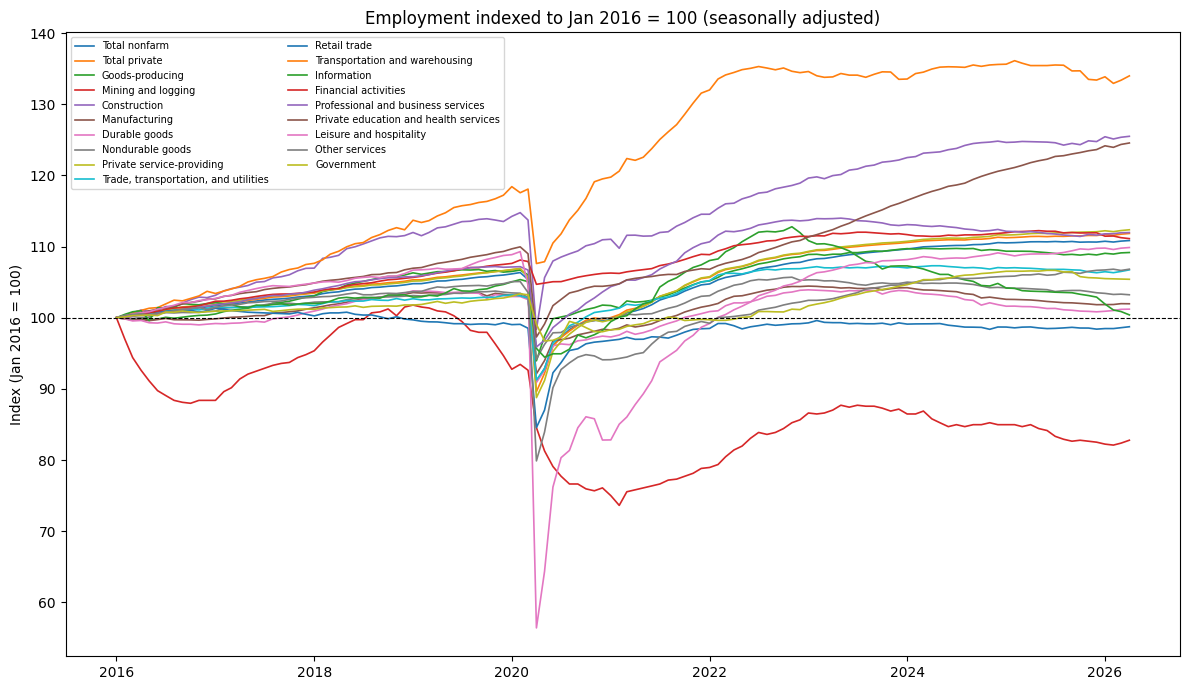

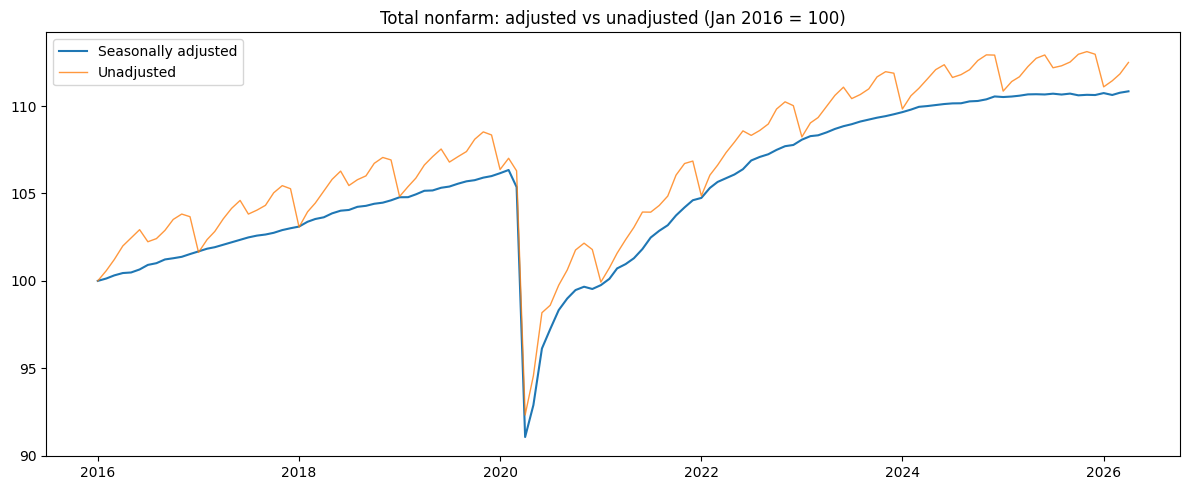

In [13]:
# 1) all supersectors, indexed
fig, ax = plt.subplots(figsize=(12, 7))
for title, row in s_idx.iterrows():
    ax.plot(x, row[month_cols].values, label=title, linewidth=1.2)
ax.axhline(100, color='k', lw=0.8, ls='--')   # the Jan 2016 baseline
ax.set(title='Employment indexed to Jan 2016 = 100 (seasonally adjusted)',
       ylabel='Index (Jan 2016 = 100)')
ax.legend(fontsize=7, ncol=2, loc='upper left')
plt.tight_layout(); plt.show()

# 2) adjusted vs unadjusted for one series — the gap is the seasonality
industry = 'Total nonfarm'
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, s_idx.loc[industry, month_cols].values, label='Seasonally adjusted', lw=1.5)
ax.plot(x, u_idx.loc[industry, month_cols].values, label='Unadjusted', lw=1.0, alpha=0.8)
ax.set(title=f'{industry}: adjusted vs unadjusted (Jan 2016 = 100)')
ax.legend(); plt.tight_layout(); plt.show()

In [14]:
top_level_s  = top_level_s.replace(r'^\s*$', np.nan, regex=True)
inflation_df = inflation_df.replace(r'^\s*$', np.nan, regex=True)

/var/folders/7j/6mqynt1d3rn3g84946r88qxr0000gn/T/ipykernel_6443/1230701604.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inflation_df = inflation_df.replace(r'^\s*$', np.nan, regex=True)


In [ ]:
def month_columns(df):
    out = []
    for c in df.columns:
        try:
            pd.to_datetime(str(c), format='%b %Y'); out.append(c)
        except (ValueError, TypeError):
            pass
    return out

def to_timeseries(df, label_col):
    mcols = month_columns(df)
    ts = df.set_index(label_col)[mcols].T
    ts.index = pd.to_datetime(ts.index, format='%b %Y')
    ts = ts.apply(pd.to_numeric, errors='coerce')   
    return ts.sort_index()

emp  = to_timeseries(top_level_s, 'CES Industry Title')
infl = to_timeseries(inflation_df, 'label')

emp.columns  = [f"EMP: {c}"   for c in emp.columns]
infl.columns = [f"PRICE: {c}" for c in infl.columns]
combined = emp.join(infl, how='inner')

changes = combined.pct_change(12).dropna(how='all')   
corr = changes.corr()
print(corr)

/var/folders/7j/6mqynt1d3rn3g84946r88qxr0000gn/T/ipykernel_6443/68625380.py:26: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  changes = combined.pct_change(12).dropna(how='all')


                                                    EMP: Total nonfarm  \
EMP: Total nonfarm                                            1.000000   
EMP: Total private                                            0.998093   
EMP: Goods-producing                                          0.948598   
EMP: Mining and logging                                       0.713044   
EMP: Construction                                             0.908961   
EMP: Manufacturing                                            0.949614   
EMP: Durable goods                                            0.932630   
EMP: Nondurable goods                                         0.945660   
EMP: Private service-providing                                0.997065   
EMP: Trade, transportation, and utilities                     0.935206   
EMP: Retail trade                                             0.873371   
EMP: Transportation and warehousing                           0.697466   
EMP: Information                      

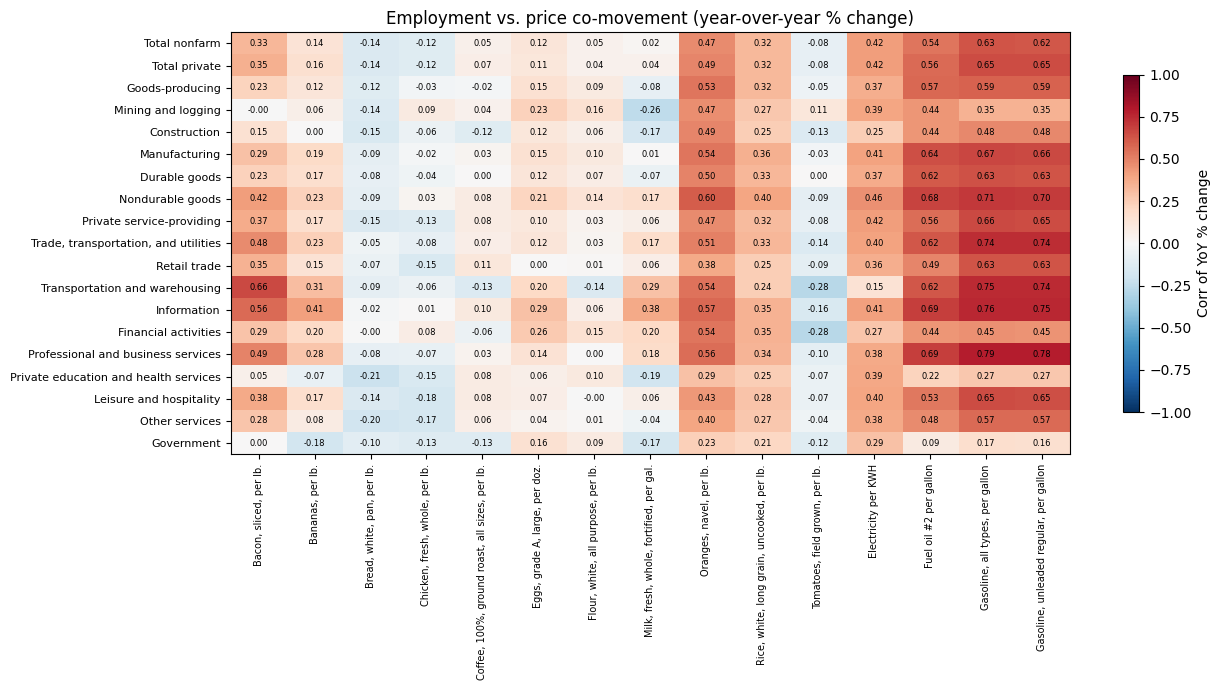

In [16]:
emp_cols   = [c for c in corr.columns if c.startswith('EMP:')]
price_cols = [c for c in corr.columns if c.startswith('PRICE:')]
cross = corr.loc[emp_cols, price_cols]

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(cross.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')

ax.set_xticks(range(len(price_cols)))
ax.set_xticklabels([c.replace('PRICE: ', '') for c in cross.columns], rotation=90, fontsize=7)
ax.set_yticks(range(len(emp_cols)))
ax.set_yticklabels([c.replace('EMP: ', '') for c in cross.index], fontsize=8)

for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        ax.text(j, i, f"{cross.values[i, j]:.2f}", ha='center', va='center', fontsize=6)

fig.colorbar(im, label='Corr of YoY % change', shrink=0.8)
ax.set_title('Employment vs. price co-movement (year-over-year % change)')
plt.tight_layout()
plt.show()

In [31]:
mcols = month_columns(inflation_df)   # both frames share these months

# --- price side: index every item to Jan 2016=100, average into one basket ---
prices = inflation_df.set_index('label')[mcols].apply(pd.to_numeric, errors='coerce')
price_idx = prices.div(prices['Jan 2016'], axis=0) * 100   # each item -> 100 at base
price_basket = price_idx.mean(axis=0)                       # one number per month

# --- jobs side: Total nonfarm, indexed to 100 ---
emp_row = top_level_s.loc[top_level_s['CES Industry Title'] == 'Total nonfarm', mcols]
emp_series = emp_row.iloc[0].astype(float)
emp_idx = emp_series / emp_series['Jan 2016'] * 100

# --- composite: equal-weight average of the two indexed series ---
composite = pd.DataFrame({'price_basket': price_basket, 'employment': emp_idx})
composite.index = pd.to_datetime(composite.index, format='%b %Y')
composite['composite_index'] = composite[['price_basket', 'employment']].mean(axis=1)
composite['stress_index'] = composite['price_basket'] - (composite['employment'] - 100)

print(composite.round(1))

            price_basket  employment  composite_index  stress_index
2016-01-01         100.0       100.0            100.0         100.0
2016-02-01          97.2       100.1             98.7          97.1
2016-03-01          97.0       100.3             98.7          96.7
2016-04-01          97.4       100.4             98.9          96.9
2016-05-01          97.9       100.5             99.2          97.4
...                  ...         ...              ...           ...
2026-08-01           NaN         NaN              NaN           NaN
2026-09-01           NaN         NaN              NaN           NaN
2026-10-01           NaN         NaN              NaN           NaN
2026-11-01           NaN         NaN              NaN           NaN
2026-12-01           NaN         NaN              NaN           NaN

[132 rows x 4 columns]


In [32]:
composite = composite.dropna().round(2)
composite

,price_basket,employment,composite_index,stress_index
2016-01-01,100.00,100.00,100.00,100.00
2016-02-01,97.24,100.14,98.69,97.10
2016-03-01,97.03,100.32,98.67,96.72
2016-04-01,97.36,100.45,98.91,96.91
2016-05-01,97.86,100.48,99.17,97.38
...,...,...,...,...
2025-12-01,136.22,110.63,123.42,125.59
2026-01-01,135.71,110.74,123.22,124.96
2026-02-01,137.47,110.63,124.05,126.84
2026-03-01,146.46,110.76,128.61,135.70


In [29]:
regional_index = pd.read_csv('regional_index.csv')
regional_index.head()

,Region,2016-01-31,2016-02-29,2016-03-31,2016-04-30,2016-05-31,2016-06-30,2016-07-31,2016-08-31,2016-09-30,...,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30
0,Midwest,100.0,100.296780,101.220051,101.951198,100.528540,100.912657,101.274725,101.397322,101.391752,...,139.138089,139.317244,139.738550,140.003761,140.221043,139.954254,139.200832,139.152274,138.703749,137.863955
1,Northeast,100.0,100.546530,101.155061,102.319640,99.979672,100.517765,100.661929,101.216577,101.096886,...,145.624589,145.437447,145.613733,145.477619,145.366830,144.947664,143.242757,142.826889,145.017166,141.329897
2,South,100.0,100.160665,100.535430,100.639275,100.793034,101.175856,101.241697,101.351269,101.407259,...,148.786478,149.152378,148.793509,148.171795,147.887493,147.407258,147.061664,147.888394,147.892160,147.600454
3,West,100.0,100.449491,101.221705,102.862957,103.688335,104.412995,105.045175,105.338023,105.499870,...,156.858951,157.288752,157.550838,157.156071,156.905344,155.611417,156.110318,156.856312,157.719954,156.316990


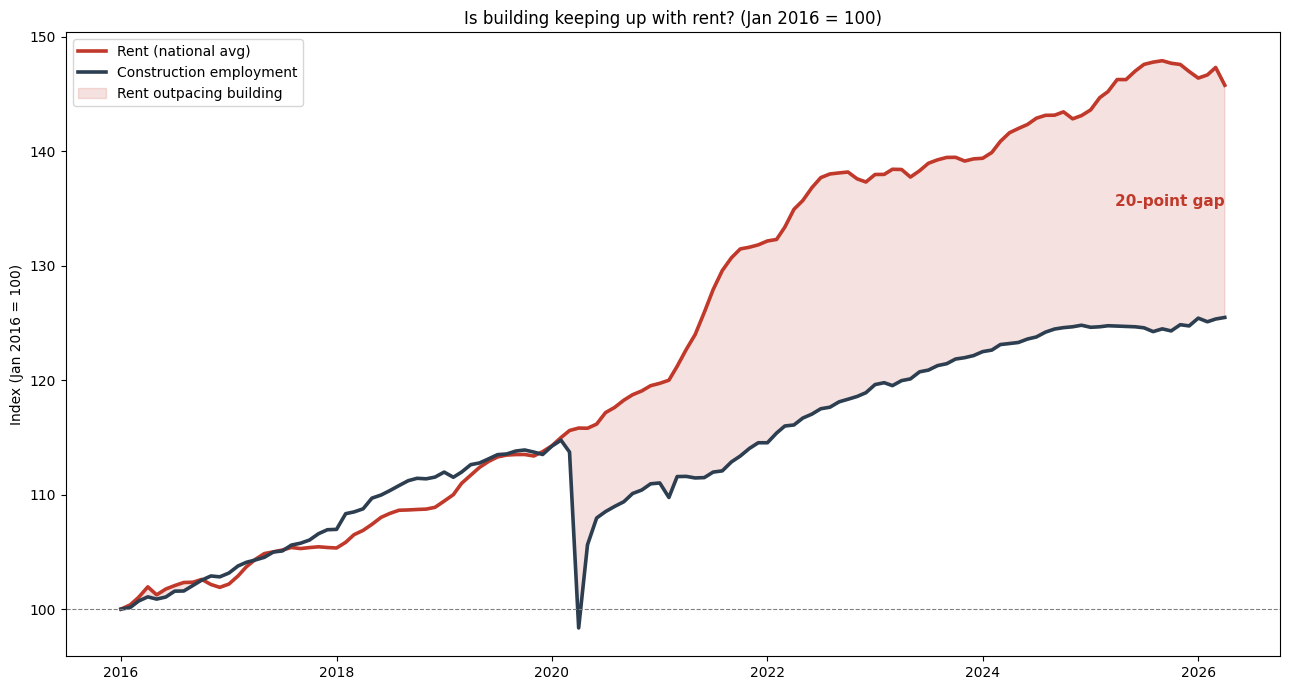

In [41]:
con = top_level_s.loc[top_level_s['CES Industry Title'] == 'Construction', month_columns(top_level_s)]
con = con.iloc[0].apply(pd.to_numeric, errors='coerce')
con_idx = con / con['Jan 2016'] * 100
con_idx.index = pd.to_datetime(con_idx.index, format='%b %Y').to_period('M')

# --- rent: average the 4 regions (already standardized to 100) ---
reg = regional_index.set_index('Region').T
reg.index = pd.to_datetime(reg.index).to_period('M')
rent = reg.mean(axis=1)

# --- align on common months ---
df = pd.DataFrame({'rent': rent, 'construction': con_idx}).dropna()
x = df.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 7))
ax.plot(x, df['rent'],         lw=2.6, color='#c0392b', label='Rent (national avg)')
ax.plot(x, df['construction'], lw=2.6, color='#2c3e50', label='Construction employment')

# shade the gap — rent above construction = supply not keeping up
ax.fill_between(x, df['construction'], df['rent'],
                where=df['rent'] >= df['construction'],
                color='#c0392b', alpha=0.15, label='Rent outpacing building')

ax.axhline(100, color='gray', lw=0.8, ls='--')
ax.set(title='Is building keeping up with rent? (Jan 2016 = 100)',
       ylabel='Index (Jan 2016 = 100)')
ax.legend(fontsize=10, loc='upper left')

last = df.iloc[-1]
ax.annotate(f"{last['rent'] - last['construction']:.0f}-point gap",
            xy=(x[-1], (last['rent'] + last['construction']) / 2),
            fontsize=11, fontweight='bold', color='#c0392b', ha='right', va='center')

plt.tight_layout(); plt.show()